# Student Performance Analysis

**Author:** Gururaj Khale
**Program:** IBM SkillsBuild Data Analytics with AI (BharatCares x AICTE)

**Goal:** Find out which everyday habits (study time, attendance, sleep, support at home) are linked to better exam scores.

## 1. Import libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (7, 4)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

## 2. Load the data

In [9]:
df = pd.read_csv('student_performance.csv')
print('Rows, columns:', df.shape)
print(df.head())

Rows, columns: (505, 10)
   student_id  gender  study_hours  attendance_pct  sleep_hours parental_support tutoring  math_score  science_score  english_score
0           1  Female          1.3            88.0          5.9             High       No        56.0           63.0           67.0
1           2    Male          3.9            91.0          6.3           Medium       No        80.0           80.0           74.0
2           3    Male          4.1            84.0          5.7             High      Yes        73.0           86.0           85.0
3           4  Female          3.7            94.0          7.6           Medium       No        69.0           76.0           85.0
4           5    Male          6.0            70.0          6.5              Low       No        66.0           81.0           71.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        505 non-null    int64  
 1   gender            505 non-null    object 
 2   study_hours       505 non-null    float64
 3   attendance_pct    489 non-null    float64
 4   sleep_hours       495 non-null    float64
 5   parental_support  505 non-null    object 
 6   tutoring          505 non-null    object 
 7   math_score        505 non-null    float64
 8   science_score     505 non-null    float64
 9   english_score     505 non-null    float64
dtypes: float64(6), int64(1), object(3)
memory usage: 39.6+ KB


In [11]:
print(df.describe().round(2))

       student_id  study_hours  attendance_pct  sleep_hours  math_score  science_score  english_score
count      505.00       505.00          489.00        495.0      505.00         505.00         505.00
mean       250.48         3.04           79.78          6.9       67.41          69.67          71.68
std        144.71         1.40            9.65          1.0       12.00          11.66          11.71
min          1.00         0.20           51.00          4.0       36.00          32.00          39.00
25%        125.00         2.00           73.00          6.2       60.00          62.00          64.00
50%        251.00         3.10           80.00          6.9       67.00          69.00          72.00
75%        375.00         3.90           87.00          7.6       76.00          78.00          79.00
max        500.00         7.50          100.00         10.0      100.00         100.00         100.00


## 3. Check data quality
Before analysing, I check for missing values and duplicate rows.

In [12]:
print('Missing values per column:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())

Missing values per column:
student_id           0
gender               0
study_hours          0
attendance_pct      16
sleep_hours         10
parental_support     0
tutoring             0
math_score           0
science_score        0
english_score        0
dtype: int64

Duplicate rows: 5


## 4. Clean the data
- Remove duplicate rows.
- Fill missing `attendance_pct` and `sleep_hours` with the **median** (the median is not pulled around by extreme values).

In [14]:
df = df.drop_duplicates()
df['attendance_pct'] = df['attendance_pct'].fillna(df['attendance_pct'].median())
df['sleep_hours'] = df['sleep_hours'].fillna(df['sleep_hours'].median())

print('Rows after cleaning:', len(df))
print('Missing values left:', df.isnull().sum().sum())

Rows after cleaning: 500
Missing values left: 0


## 5. Create new columns
I add an **average score** across the three subjects and a **grade band**.

In [15]:
df['average_score'] = df[['math_score', 'science_score', 'english_score']].mean(axis=1).round(1)

def get_grade(score):
    if score >= 75:
        return 'A'
    elif score >= 60:
        return 'B'
    elif score >= 45:
        return 'C'
    else:
        return 'D'

df['grade'] = df['average_score'].apply(get_grade)
print(df[['student_id', 'average_score', 'grade']].head())
print()
print(df['grade'].value_counts().sort_index())

   student_id  average_score grade
0           1           62.0     B
1           2           78.0     A
2           3           81.3     A
3           4           76.7     A
4           5           72.7     B

grade
A    152
B    254
C     90
D      4
Name: count, dtype: int64


## 6. Exploratory analysis

### 6.1 How are the average scores spread out?

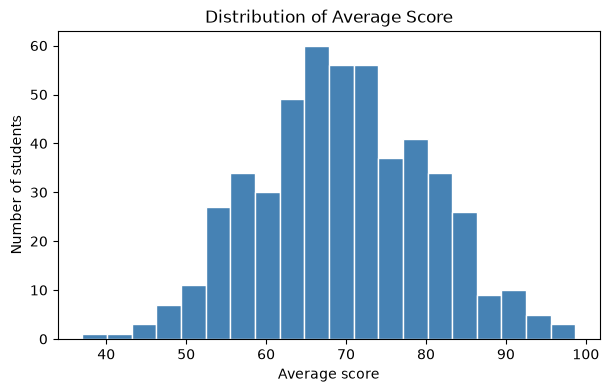

Mean average score: 69.6
Median average score: 69.7


In [16]:
plt.hist(df['average_score'], bins=20, color='steelblue', edgecolor='white')
plt.title('Distribution of Average Score')
plt.xlabel('Average score')
plt.ylabel('Number of students')
plt.show()

print('Mean average score:', round(df['average_score'].mean(), 1))
print('Median average score:', df['average_score'].median())

### 6.2 Subject-wise comparison

math_score       67.4
science_score    69.7
english_score    71.7
dtype: float64


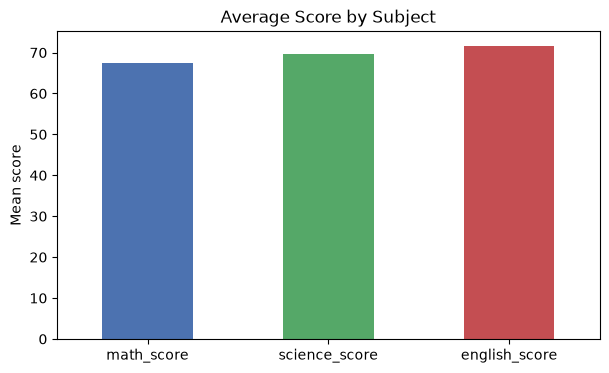

In [17]:
subject_means = df[['math_score', 'science_score', 'english_score']].mean().round(1)
print(subject_means)

subject_means.plot(kind='bar', color=['#4c72b0', '#55a868', '#c44e52'])
plt.title('Average Score by Subject')
plt.ylabel('Mean score')
plt.xticks(rotation=0)
plt.show()

### 6.3 Does study time matter?

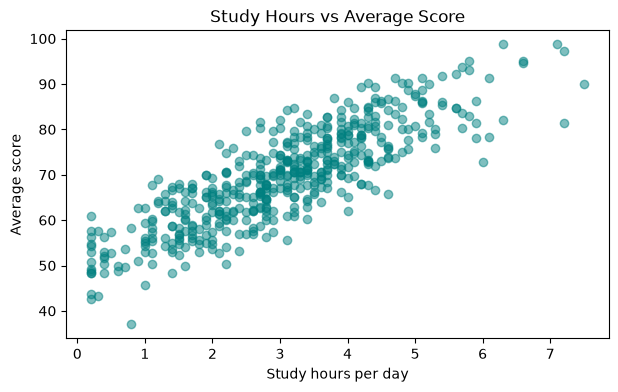

Correlation: 0.85


In [18]:
plt.scatter(df['study_hours'], df['average_score'], alpha=0.5, color='teal')
plt.title('Study Hours vs Average Score')
plt.xlabel('Study hours per day')
plt.ylabel('Average score')
plt.show()

print('Correlation:', round(df['study_hours'].corr(df['average_score']), 2))

### 6.4 Does attendance matter?

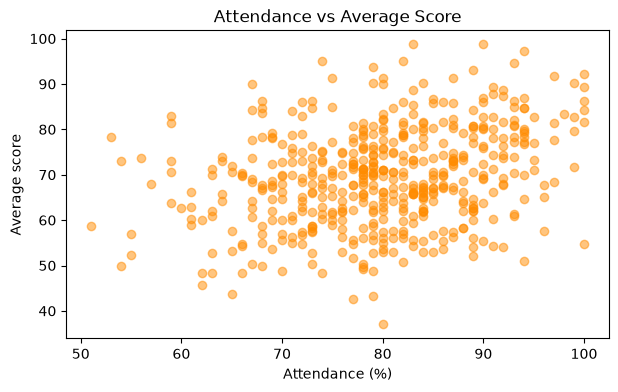

Correlation: 0.3


In [19]:
plt.scatter(df['attendance_pct'], df['average_score'], alpha=0.5, color='darkorange')
plt.title('Attendance vs Average Score')
plt.xlabel('Attendance (%)')
plt.ylabel('Average score')
plt.show()

print('Correlation:', round(df['attendance_pct'].corr(df['average_score']), 2))

### 6.5 Parental support and tutoring

parental_support
Low       66.5
Medium    69.6
High      72.2
Name: average_score, dtype: float64

tutoring
No     68.4
Yes    72.2
Name: average_score, dtype: float64


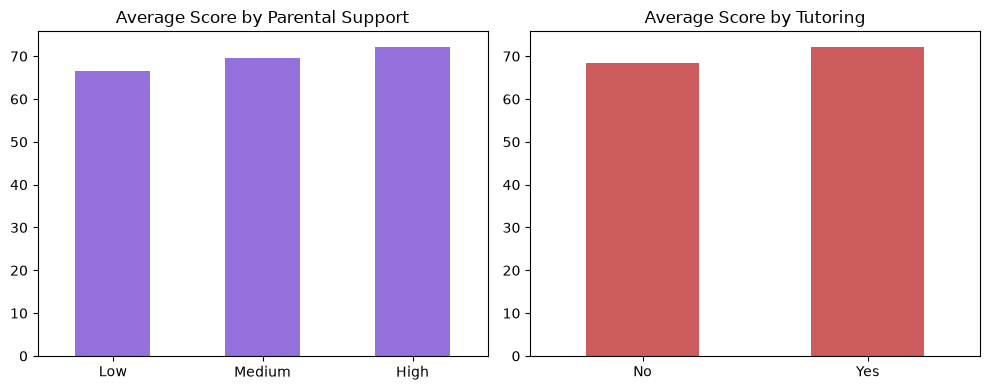

In [20]:
support = df.groupby('parental_support')['average_score'].mean().round(1).reindex(['Low', 'Medium', 'High'])
tutoring = df.groupby('tutoring')['average_score'].mean().round(1)
print(support)
print()
print(tutoring)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
support.plot(kind='bar', ax=axes[0], color='mediumpurple')
axes[0].set_title('Average Score by Parental Support')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
tutoring.plot(kind='bar', ax=axes[1], color='indianred')
axes[1].set_title('Average Score by Tutoring')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### 6.6 Gender comparison

In [21]:
print(df.groupby('gender')[['math_score', 'science_score', 'english_score', 'average_score']].mean().round(1))

        math_score  science_score  english_score  average_score
gender                                                         
Female        69.1           70.8           72.2           70.7
Male          65.9           68.7           71.2           68.6


## 7. Correlation between numeric columns

                study_hours  attendance_pct  sleep_hours  average_score
study_hours            1.00            0.09         0.03           0.85
attendance_pct         0.09            1.00        -0.01           0.30
sleep_hours            0.03           -0.01         1.00           0.12
average_score          0.85            0.30         0.12           1.00


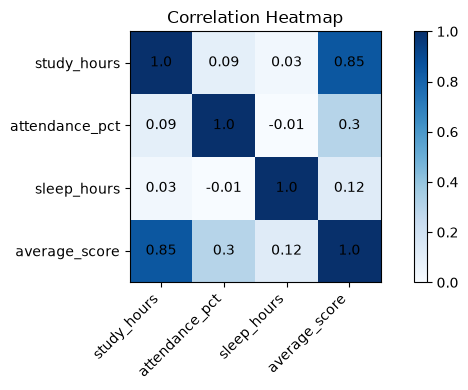

In [23]:
num_cols = ['study_hours', 'attendance_pct', 'sleep_hours', 'average_score']
corr = df[num_cols].corr().round(2)
print(corr)

plt.imshow(corr, cmap='Blues', vmin=0, vmax=1)
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=45, ha='right')
plt.yticks(range(len(num_cols)), num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        plt.text(j, i, corr.iloc[i, j], ha='center', va='center')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 8. Simple prediction: study hours -> average score
A straight-line (linear regression) fit using NumPy.

Slope: 6.49 (score gained per extra study hour)
Intercept: 49.88
R-squared: 0.71


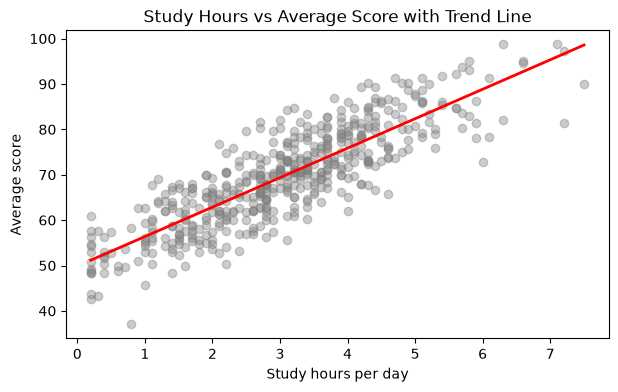

Predicted score for 2 study hours/day: 62.9
Predicted score for 4 study hours/day: 75.9
Predicted score for 6 study hours/day: 88.8


In [24]:
x = df['study_hours']
y = df['average_score']

slope, intercept = np.polyfit(x, y, 1)
predicted = slope * x + intercept

ss_res = ((y - predicted) ** 2).sum()
ss_tot = ((y - y.mean()) ** 2).sum()
r_squared = 1 - ss_res / ss_tot

print('Slope:', round(slope, 2), '(score gained per extra study hour)')
print('Intercept:', round(intercept, 2))
print('R-squared:', round(r_squared, 2))

plt.scatter(x, y, alpha=0.4, color='gray')
line_x = np.linspace(x.min(), x.max(), 50)
plt.plot(line_x, slope * line_x + intercept, color='red', linewidth=2)
plt.title('Study Hours vs Average Score with Trend Line')
plt.xlabel('Study hours per day')
plt.ylabel('Average score')
plt.show()

for h in [2, 4, 6]:
    print(f'Predicted score for {h} study hours/day:', round(slope * h + intercept, 1))

## 9. Conclusions
- The average score is about **69.6** out of 100. Most students are in grade B (254 of 500).
- **Study hours** has the strongest link with scores (correlation **0.85**). The trend line says each extra hour of daily study is linked to roughly **6.5 more marks** (R-squared 0.71).
- **Attendance** has a moderate link (**0.30**) and **sleep** a weak one (**0.12**).
- Students with **high parental support** average about 72.2 versus 66.5 for low support. Students with **tutoring** average about 72.2 versus 68.4 without.
- Female students average about 2 marks higher than male students. This gap is small and may just be chance.
- Subject-wise, English has the highest average (71.7) and Maths the lowest (67.4).

**Limitations:** the data is a sample dataset generated for learning, so these results only show how the analysis works. Correlation does not prove that one thing causes another.

**Next steps:** try the analysis on a real dataset, and try more models (for example multiple regression).